In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [4]:
# 1. Baca data
df = pd.read_csv('housing.csv')
df.head()

,id,lokasi,luas_tanah,luas_bangunan,kamar_tidur,kamar_mandi,kapasitas_garasi,usia_bangunan,jarak_pusat_kota_km,harga_juta
0,1,Jakarta Selatan,137,94,3,2,1,11,3.8,2486.53
1,2,Jakarta Selatan,115,75,2,1,1,16,14.5,1737.78
2,3,Tangerang Selatan,143,118,3,2,1,6,21.8,1924.88
3,4,Bekasi,173,146,3,3,2,8,15.6,1760.58
4,5,Bekasi,112,100,3,3,1,2,7.2,1304.81


In [10]:
# 2. Mengubah kolom 'lokasi' menjadi beberapa kolom angka
df_encoded = pd.get_dummies(df, columns=['lokasi'], drop_first=True)
# Menampilkan 5 data pertama
df_encoded.head()

,id,luas_tanah,luas_bangunan,kamar_tidur,kamar_mandi,kapasitas_garasi,usia_bangunan,jarak_pusat_kota_km,harga_juta,lokasi_Depok,lokasi_Jakarta Barat,lokasi_Jakarta Selatan,lokasi_Tangerang Selatan
0,1,137,94,3,2,1,11,3.8,2486.53,False,False,True,False
1,2,115,75,2,1,1,16,14.5,1737.78,False,False,True,False
2,3,143,118,3,2,1,6,21.8,1924.88,False,False,False,True
3,4,173,146,3,3,2,8,15.6,1760.58,False,False,False,False
4,5,112,100,3,3,1,2,7.2,1304.81,False,False,False,False


In [6]:
# 3. Pisahkan fitur dan target
X = df_encoded.drop(columns=['id', 'harga_juta'])
y = df_encoded['harga_juta']

In [46]:
# 4. Split train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("--- Ukuran Dataset ---")
print(f"X_train (Training Data 80%): {X_train.shape}")
print(f"X_test (Testing Data 20%) : {X_test.shape}")

--- Ukuran Dataset ---
X_train (Training Data 80%): (240, 11)
X_test (Testing Data 20%) : (60, 11)


In [8]:
# 5. Fit model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
print(f"R² Score: {model.score(X_test, y_test):.4f}")

R² Score: 0.9768


In [11]:
y_pred = model.predict(X_test)
residuals = y_test - y_pred

In [21]:
# 1. Buat DataFrame hasil prediksi
df_hasil = X_test.copy()
df_hasil['Harga_Aktual'] = y_test
df_hasil['Harga_Prediksi'] = y_pred.round(2)
df_hasil['Error'] = residuals.round(2)
df_hasil['Error_%'] = (abs(residuals) /y_test * 100).round(2)

# 2. Tampilkan 10 baris teratas
df_hasil.head(10)

,luas_tanah,luas_bangunan,kamar_tidur,kamar_mandi,kapasitas_garasi,usia_bangunan,jarak_pusat_kota_km,lokasi_Depok,lokasi_Jakarta Barat,lokasi_Jakarta Selatan,lokasi_Tangerang Selatan,Harga_Aktual,Harga_Prediksi,Error,Error_%
203,157,101,3,3,1,18,6.9,False,False,True,False,2584.40,2523.30,61.10,2.36
266,177,137,3,2,2,6,8.2,False,True,False,False,2818.33,2678.43,139.90,4.96
152,96,71,2,1,1,11,14.2,False,False,False,False,849.04,801.20,47.84,5.63
9,139,122,3,2,1,0,4.3,True,False,False,False,1757.76,1800.55,-42.79,2.43
233,97,80,1,1,1,17,15.7,False,False,True,False,1508.15,1640.36,-132.21,8.77
226,122,96,3,2,1,22,18.6,False,False,False,True,1454.47,1450.72,3.75,0.26
196,89,67,1,1,1,6,8.1,True,False,False,False,964.85,871.84,93.01,9.64
109,117,83,3,2,1,14,23.8,False,False,False,True,1286.49,1354.28,-67.79,5.27
5,112,81,2,1,2,12,10.8,False,False,False,True,1422.99,1446.14,-23.15,1.63
175,149,99,3,2,2,7,9.0,False,True,False,False,2251.75,2224.68,27.07,1.20


In [38]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prediksi data uji
y_pred_test = model.predict(X_test)

# Hitung metrik evaluasi
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print(
    f'MAE      : Rata-rata kesalahan absolut prediksi harga rumah sebesar'
    f' {mae:.2f}'
)
print(
    'MSE      : Rata-rata kuadrat selisih antara harga asli dan harga prediksi'
    f' adalah {mse:.2f}'
)
print(
    'RMSE     : Rata-rata selisih tebakan harga rumah dari harga asli sebesar'
    f' {rmse:.2f}'
)
print(f'R-Square : {r2:.4f} ({r2*100:.2f}% harga rumah dapat diprediksi)')

MAE      : Rata-rata kesalahan absolut prediksi harga rumah sebesar 70.71
MSE      : Rata-rata kuadrat selisih antara harga asli dan harga prediksi adalah 8477.08
RMSE     : Rata-rata selisih tebakan harga rumah dari harga asli sebesar 92.07
R-Square : 0.9768 (97.68% harga rumah dapat diprediksi)


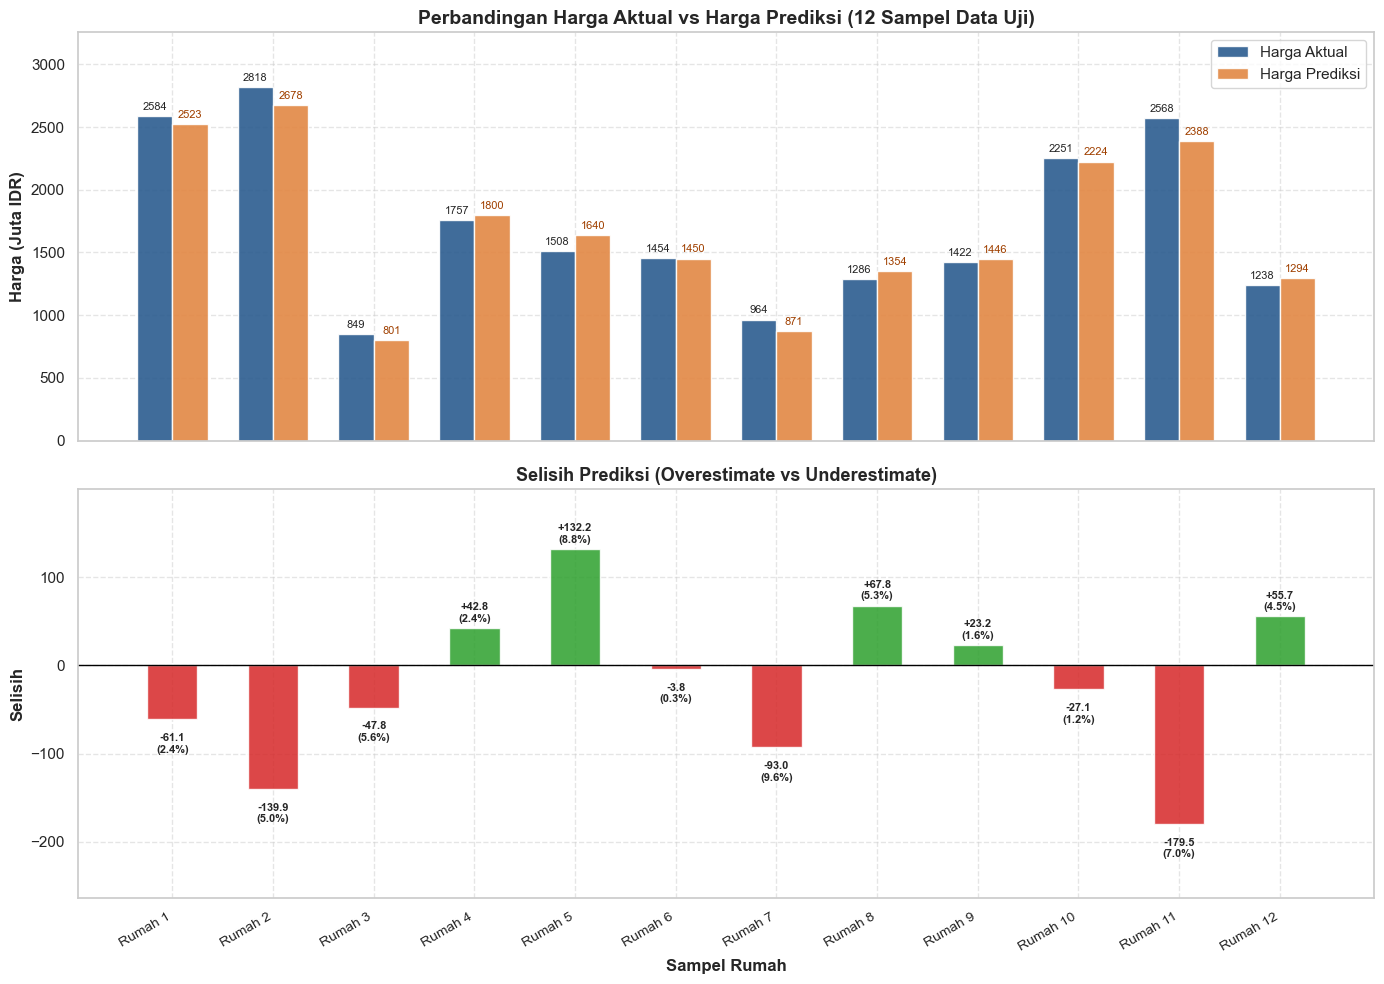

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# 1. Olah data & latih model
df = pd.read_csv('housing.csv')
df_encoded = pd.get_dummies(df, columns=['lokasi'], drop_first=True)

X = df_encoded.drop(columns=['id', 'harga_juta'])
y = df_encoded['harga_juta']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 2. Ambil 12 sampel pertama dari data uji untuk divisualisasikan
df_eval = pd.DataFrame({'Aktual': y_test.values, 'Prediksi': y_pred}).head(12)

df_eval['Selisih'] = df_eval['Prediksi'] - df_eval['Aktual']
df_eval['Error_Pct'] = (np.abs(df_eval['Selisih']) / df_eval['Aktual']) * 100
df_eval['Sample'] = [f'Rumah {i+1}' for i in range(len(df_eval))]

# 3. Setup canvas
sns.set_theme(style='whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

x = np.arange(len(df_eval))
width = 0.35

# Plot 1: Perbandingan Harga Aktual vs Prediksi
bars1 = ax1.bar(
    x - width / 2,
    df_eval['Aktual'],
    width,
    label='Harga Aktual',
    color='#2b5c8f',
    alpha=0.9,
)
bars2 = ax1.bar(
    x + width / 2,
    df_eval['Prediksi'],
    width,
    label='Harga Prediksi',
    color='#e28743',
    alpha=0.9,
)

ax1.set_ylabel('Harga (Juta IDR)', fontsize=12, fontweight='bold')
ax1.set_title(
    'Perbandingan Harga Aktual vs Harga Prediksi (12 Sampel Data Uji)',
    fontsize=14,
    fontweight='bold',
)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

# Anotasi angka pada grafik atas
for bar in bars1:
  h = bar.get_height()
  ax1.annotate(
      f'{int(h)}',
      xy=(bar.get_x() + bar.get_width() / 2, h),
      xytext=(0, 3),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=8,
  )
for bar in bars2:
  h = bar.get_height()
  ax1.annotate(
      f'{int(h)}',
      xy=(bar.get_x() + bar.get_width() / 2, h),
      xytext=(0, 3),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=8,
      color='#a04000',
  )

# Plot 2: Selisih Prediksi (Error bar chart)
colors = ['#2ca02c' if val >= 0 else '#d62728' for val in df_eval['Selisih']]
bars3 = ax2.bar(x, df_eval['Selisih'], width=0.5, color=colors, alpha=0.85)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_ylabel('Selisih', fontsize=12, fontweight='bold')
ax2.set_xlabel('Sampel Rumah', fontsize=12, fontweight='bold')
ax2.set_title(
    'Selisih Prediksi (Overestimate vs Underestimate)',
    fontsize=13,
    fontweight='bold',
)
ax2.set_xticks(x)
ax2.set_xticklabels(df_eval['Sample'], rotation=30, ha='right', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)

# Anotasi selisih dan persentase error pada grafik bawah
for bar, err_pct in zip(bars3, df_eval['Error_Pct']):
  h = bar.get_height()
  va = 'bottom' if h >= 0 else 'top'
  y_offset = 3 if h >= 0 else -10
  ax2.annotate(
      f'{h:+.1f}\n({err_pct:.1f}%)',
      xy=(bar.get_x() + bar.get_width() / 2, h),
      xytext=(0, y_offset),
      textcoords='offset points',
      ha='center',
      va=va,
      fontsize=8,
      fontweight='bold',
  )

# Atur batas sumbu y agar teks anotasi tidak terpotong
y1_min, y1_max = ax1.get_ylim()
ax1.set_ylim(y1_min, y1_max * 1.1)

y2_min, y2_max = ax2.get_ylim()
ax2.set_ylim(y2_min * 1.35, y2_max * 1.35)

plt.tight_layout()
plt.show()